In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("output.csv")

In [ ]:
from sklearn.metrics import f1_score
import numpy as np
np.mean((df["wandb_neg"] == df["label_neg"]))

np.float64(0.85)

In [ ]:
RUNS = {
    "y5uoiof7": "VSF",
    "wtbgflvh": "NASA",
    "67mdtd5b": "NAG",
    "ut7lp63l": "NAG++"
}

In [ ]:
df["name"] = df["run_id"].apply(lambda x: RUNS[x])

NameError: name 'df' is not defined

In [ ]:
df[[ "label_pos", "label_neg", "label_quality", "name"]].groupby("name").mean()

,label_pos,label_neg,label_quality
name,,,
NAG,0.95,0.25,0.6750
NAG++,1.00,0.10,0.8950
NASA,0.95,0.15,0.6850
VSF,0.90,0.55,0.8225


In [ ]:
df[[ "label_pos", "label_neg", "label_quality", "name"]].groupby("name").mean().style.format(precision=3).to_latex()

'\\begin{tabular}{lrrr}\n & label_pos & label_neg & label_quality \\\\\nname &  &  &  \\\\\nNAG & 0.950 & 0.250 & 0.675 \\\\\nNAG++ & 1.000 & 0.100 & 0.895 \\\\\nNASA & 0.950 & 0.150 & 0.685 \\\\\nVSF & 0.900 & 0.550 & 0.823 \\\\\n\\end{tabular}\n'

In [ ]:
rel = {
    "Negative Score": {},
    "Positive Score": {},
    # "Quality Score": {}
}

In [ ]:
rel["Negative Score"]["F1"] = f1_score(df["wandb_neg"], df["label_neg"])

In [ ]:
rel["Positive Score"]["F1"] = f1_score(df["wandb_pos"], df["label_pos"])

In [ ]:
rel["Negative Score"]["Accuracy"] = np.mean((df["wandb_neg"] == df["label_neg"]))
rel["Positive Score"]["Accuracy"] = np.mean((df["wandb_pos"] == df["label_pos"]))

In [ ]:
df["wandb_quality_z"] = (df["wandb_quality"] - df["wandb_quality"].mean())/df["wandb_quality"].std()
df["label_quality_z"] = (df["label_quality"] - df["label_quality"].mean())/df["label_quality"].std()

In [ ]:
f1_score((df["wandb_quality"]<1), (df["label_quality_z"]<0))

0.2777777777777778

In [ ]:
label_quality = list(df["label_quality"])
wandb_quality = list(df["wandb_quality"])

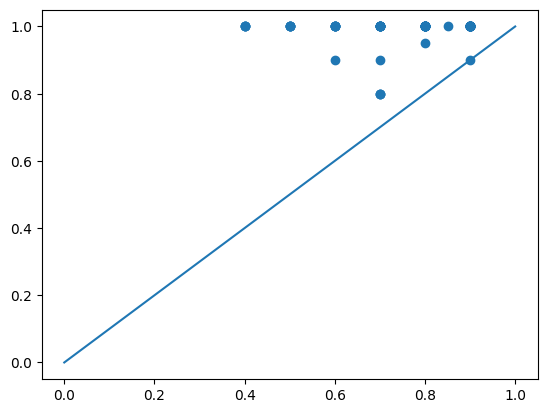

In [ ]:
import pylab
pylab.scatter(df["label_quality"], df["wandb_quality"])
pylab.plot([0,1], [0,1])

In [ ]:
import json
labeled = []
with open("annotations.jsonl", "r") as f:
  for line in f:
    labeled_line = json.loads(line)
    try:
      labeled.append({"image": labeled_line["image"].split(".")[0].replace("_png",""), "quality": float(labeled_line["suffix"])})
    except:
      pass

In [ ]:

with open("data.json", "r") as f:
  data = json.load(f)
  for i in data:
    filename = i["filename"]
    for idx, j in enumerate(labeled):
      if j["image"] == filename:
        labeled[idx]["wandb_quality"] = float(i["scores"][-1])

In [ ]:

with open("data2.json", "r") as f:
  data = json.load(f)
  for i in data:
    filename = i["filename"]
    for idx, j in enumerate(labeled):
      if j["image"] == filename:
        labeled[idx]["wandb_quality"] = float(i["scores"][-1])

In [ ]:

with open("data3.json", "r") as f:
  data = json.load(f)
  for i in data:
    filename = i["filename"]
    for idx, j in enumerate(labeled):
      if j["image"] == filename:
        labeled[idx]["wandb_quality"] = float(i["scores"][-1])

In [ ]:
labeled = pd.DataFrame(labeled)

In [ ]:
labeled["quality"][0]

np.float64(0.0)

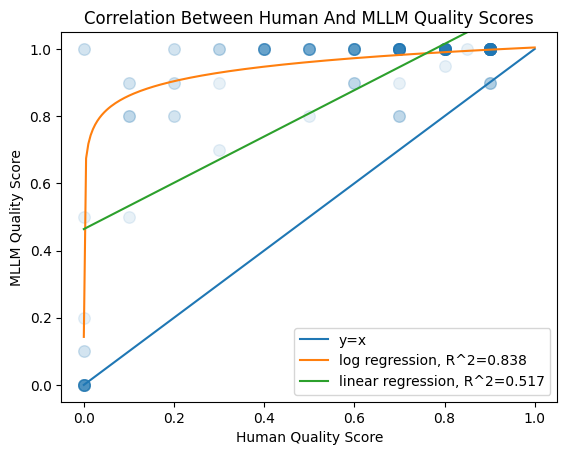

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import pylab

x = np.array(list(df["label_quality"]) + list(labeled["quality"]))
y = np.array(list(df["wandb_quality"]) + list(labeled["wandb_quality"]))

mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

bias = 1e-6
def log_func(x, a, b):
    return a * np.log(x + bias) + b

params, _ = curve_fit(log_func, x, y, maxfev=10000)

y_pred = log_func(x, *params)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)

x_fit = np.linspace(0, 1, 200)
y_fit = log_func(x_fit, *params)

m, c = np.polyfit(x, y, 1)
y_lin_pred = m * x + c
ss_res_lin = np.sum((y - y_lin_pred) ** 2)
ss_tot_lin = np.sum((y - np.mean(y)) ** 2)
r2_lin = 1 - (ss_res_lin / ss_tot_lin)
x_lin_fit = np.linspace(0, 1, 200)
y_lin_fit = m * x_lin_fit + c

pylab.scatter(x, y, alpha=0.1, s=70)
pylab.plot([0,1], [0,1], label="y=x")
pylab.plot(x_fit, y_fit, label=f"log regression, R^2={r2:.3f}")
pylab.plot(x_lin_fit, y_lin_fit, label=f"linear regression, R^2={r2_lin:.3f}")
pylab.legend()
pylab.xlabel("Human Quality Score")
pylab.ylabel("MLLM Quality Score")
pylab.title("Correlation Between Human And MLLM Quality Scores")
pylab.ylim(-0.05,1.05)
pylab.xlim(-0.05,1.05)
pylab.show()


In [ ]:
pd.DataFrame(rel).style.format(precision=3).to_latex()

'\\begin{tabular}{lrr}\n & Negative Score & Positive Score \\\\\nF1 & 0.667 & 0.974 \\\\\nAccuracy & 0.850 & 0.950 \\\\\n\\end{tabular}\n'